# **Projekt Zaliczeniowy: Wizja Komputerowa w Systemach Bezpieczeństwa (ADAS)**

### **Kontekst:**
Pracujesz w dziale R\&D firmy rozwijającej systemy unikania kolizji dla pojazdów autonomicznych. Twój zespół odpowiada za "Moduł Wykrywania Obiektów Żywych". Twoim zadaniem jest zbudowanie dwóch prototypowych modeli wizyjnych:

1. **Model detekcji wtargnięć zwierząt** (Segmentacja Semantyczna), który rozumie ogólny zarys obiektu.  
2. **Model śledzenia pieszych na przejściach** (Segmentacja Instancji), który potrafi precyzyjnie rozróżnić i wyizolować poszczególne osoby z tłumu.


## **Część 1: Segmentacja Semantyczna (Detekcja Zwierząt)**

### **Cel:** Wytrenowanie lub douczenie (fine-tuning) modelu, który przypisze każdemu pikselowi na obrazie odpowiednią klasę, co pozwoli na precyzyjne odcięcie sylwetki zwierzęcia od tła.

### **Wymagane Dane:**

Do tego zadania wykorzystasz zbiór **Oxford-IIIT Pet Dataset**. Zbiór ten ma zostać pobrany w sposób zautomatyzowany za pomocą wbudowanej klasy torchvision.datasets.OxfordIIITPet (z flagą download=True oraz target_types='segmentation').

* **Format masek:** Oryginalne maski w tym zbiorze przyjmują wartości pikseli: 1 (sylwetka zwierzęcia), 2 (tło) oraz 3 (krawędź/obrys).  
* **Zadanie inżynierii danych:** W klasie Dataset trzeba zaimplementować przesunięcie tych wartości na 0, 1, 2, aby były poprawnie interpretowane przez funkcję straty CrossEntropyLoss (gdzie indeks 0 standardowo odpowiada tłu).

### **Zadania:**

1. Przygotowanie klasy automatycznie wczytującej i transformującej dane (wymagane użycie torchvision.transforms.v2 do jednoczesnego skalowania obrazu i maski do rozmiaru 256x256).  
2. Załadowanie modelu **DeepLabV3** lub **U-Net** z biblioteki torchvision.  
3. Modyfikacja warstwy klasyfikatora do obsługi **3 klas**.  
4. Zbudowanie pętli uczącej i monitorowanie błędu (Loss) na podzbiorze treningowym.
5. **Ewaluacja Metryką:** Zaimplementowanie funkcji obliczającej metrykę **mIoU (mean Intersection over Union)** i sprawdzenie jej wyniku na zbiorze testowym/walidacyjnym po zakończeniu treningu.
6. **Inferencja i Wizualizacja:** Pobranie 3 losowych obrazów, na których model nie był uczony (zbiór testowy). Wykonanie predykcji i zestawienie wyników na wykresie z użyciem matplotlib w formacie: **Oryginalny Obraz | Prawdziwa Maska (Ground Truth) | Maska Przewidziana przez Model**.





In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torchvision import tv_tensors
import matplotlib.pyplot as plt

class OxfordPetDataset(torch.utils.data.Dataset):
    def __init__(self, root, split="trainval", transform=None):
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        # Opakowanie w odpowiednie klasy tv_tensors dla v2 transforms
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(mask)

        if self.transform:
            image, mask = self.transform(image, mask)

        # Konwersja maski na typ long i przesunięcie wartości z {1,2,3} na {0,1,2}
        mask = mask.to(torch.long) - 1

        # Usunięcie zbędnego wymiaru kanału z maski (jeśli występuje), aby pasowała do CrossEntropyLoss
        if mask.ndim == 3:
            mask = mask.squeeze(0)

        return image, mask

# Transformacje v2 jednoczesne dla obrazu i maski
transforms = v2.Compose([
    v2.Resize((256, 256), antialias=True),
    v2.ToDtype(torch.float32, scale=True) # Skaluje obraz do [0, 1]
])

# Inicjalizacja zbiorów
train_dataset = OxfordPetDataset(root='./data', split='trainval', transform=transforms)
test_dataset = OxfordPetDataset(root='./data', split='test', transform=transforms)

print(f"Rozmiar zbioru treningowego: {len(train_dataset)}")
img, mask = train_dataset[0]
print(f"Kształt obrazu: {img.shape}")
print(f"Kształt maski: {mask.shape}")
print(f"Unikalne wartości w masce: {torch.unique(mask)}")

100%|██████████| 792M/792M [00:36<00:00, 21.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.90MB/s]


Rozmiar zbioru treningowego: 3680
Kształt obrazu: torch.Size([3, 256, 256])
Kształt maski: torch.Size([256, 256])
Unikalne wartości w masce: tensor([0, 1, 2])


In [ ]:
from torch.utils.data import DataLoader

# Przygotowanie DataLoaderów
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torchvision.models.segmentation as segmentation
from torchvision.models.segmentation.deeplabv3 import DeepLabHead


# Ładowanie modelu DeepLabV3
model = segmentation.deeplabv3_resnet50(weights='DEFAULT')

# Modyfikacja klasyfikatora pod 3 klasy (nasz use-case)
model.classifier = DeepLabHead(2048, 3)
model = model.to(device)

In [3]:
from tqdm.auto import tqdm

# Funkcja straty i optymalizator
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Dodanie tqmd jako wrappera na train_loader
    progress_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{num_epochs}")

    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # DeepLabV3 zwraca dict, z którego nas interesuje 'out'
        outputs = model(images)['out']

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Aktualizujemy informacje na pasku postępu (bieżący loss batcha)
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Średni Błąd (Loss) dla epoki {epoch+1}: {epoch_loss:.4f}")

Epoka 1/3:   0%|          | 0/460 [00:00<?, ?it/s]

Średni Błąd (Loss) dla epoki 1: 0.1555


Epoka 2/3:   0%|          | 0/460 [00:00<?, ?it/s]

Średni Błąd (Loss) dla epoki 2: 0.1402


Epoka 3/3:   0%|          | 0/460 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3f5c59cf40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3f5c59cf40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Średni Błąd (Loss) dla epoki 3: 0.1318


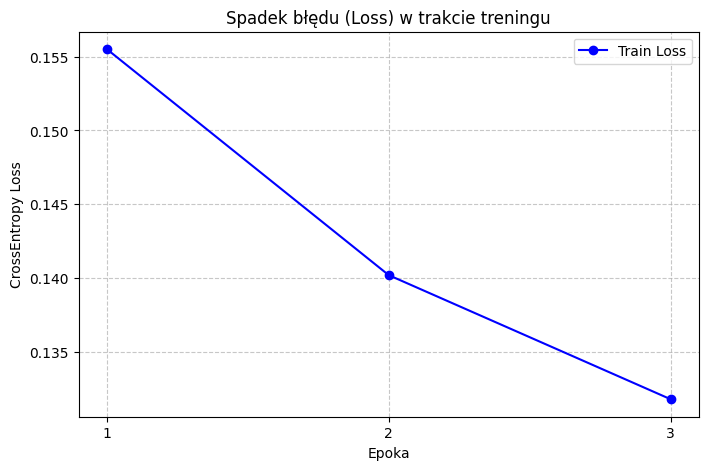

In [5]:
import matplotlib.pyplot as plt

train_losses_history = [0.1555, 0.1402, 0.1318]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses_history) + 1), train_losses_history, marker='o', linestyle='-', color='b', label='Train Loss')
plt.title('Spadek błędu (Loss) w trakcie treningu')
plt.xlabel('Epoka')
plt.ylabel('CrossEntropy Loss')
plt.xticks(range(1, len(train_losses_history) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Punkt 5: Ewaluacja Metryką mIoU

In [6]:
import numpy as np

def calculate_iou(pred_mask, true_mask, num_classes=3):
    # Zamiana prawdopodobieństw na indeksy klas (B, C, H, W) -> (B, H, W)
    pred_mask = torch.argmax(pred_mask, dim=1)

    ious = []
    for cls in range(num_classes):
        pred_inds = (pred_mask == cls)
        true_inds = (true_mask == cls)

        intersection = (pred_inds & true_inds).sum().item()
        union = (pred_inds | true_inds).sum().item()

        # Jeśli danej klasy nie ma na obrazie w ogóle, ignorujemy ją w liczeniu średniej dla tego batcha
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return np.nanmean(ious)

# Pętla walidacyjna na zbiorze testowym
model.eval()
all_ious = []

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Ewaluacja mIoU")
    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']
        iou = calculate_iou(outputs, masks)
        all_ious.append(iou)

        progress_bar.set_postfix({'mIoU': f"{iou:.4f}"})

final_miou = np.mean(all_ious)
print(f"\nŚrednie mIoU na całym zbiorze testowym: {final_miou:.4f}")

Ewaluacja mIoU:   0%|          | 0/459 [00:00<?, ?it/s]


Średnie mIoU na całym zbiorze testowym: 0.7987


### Punkt 6: Inferencja i Wizualizacja

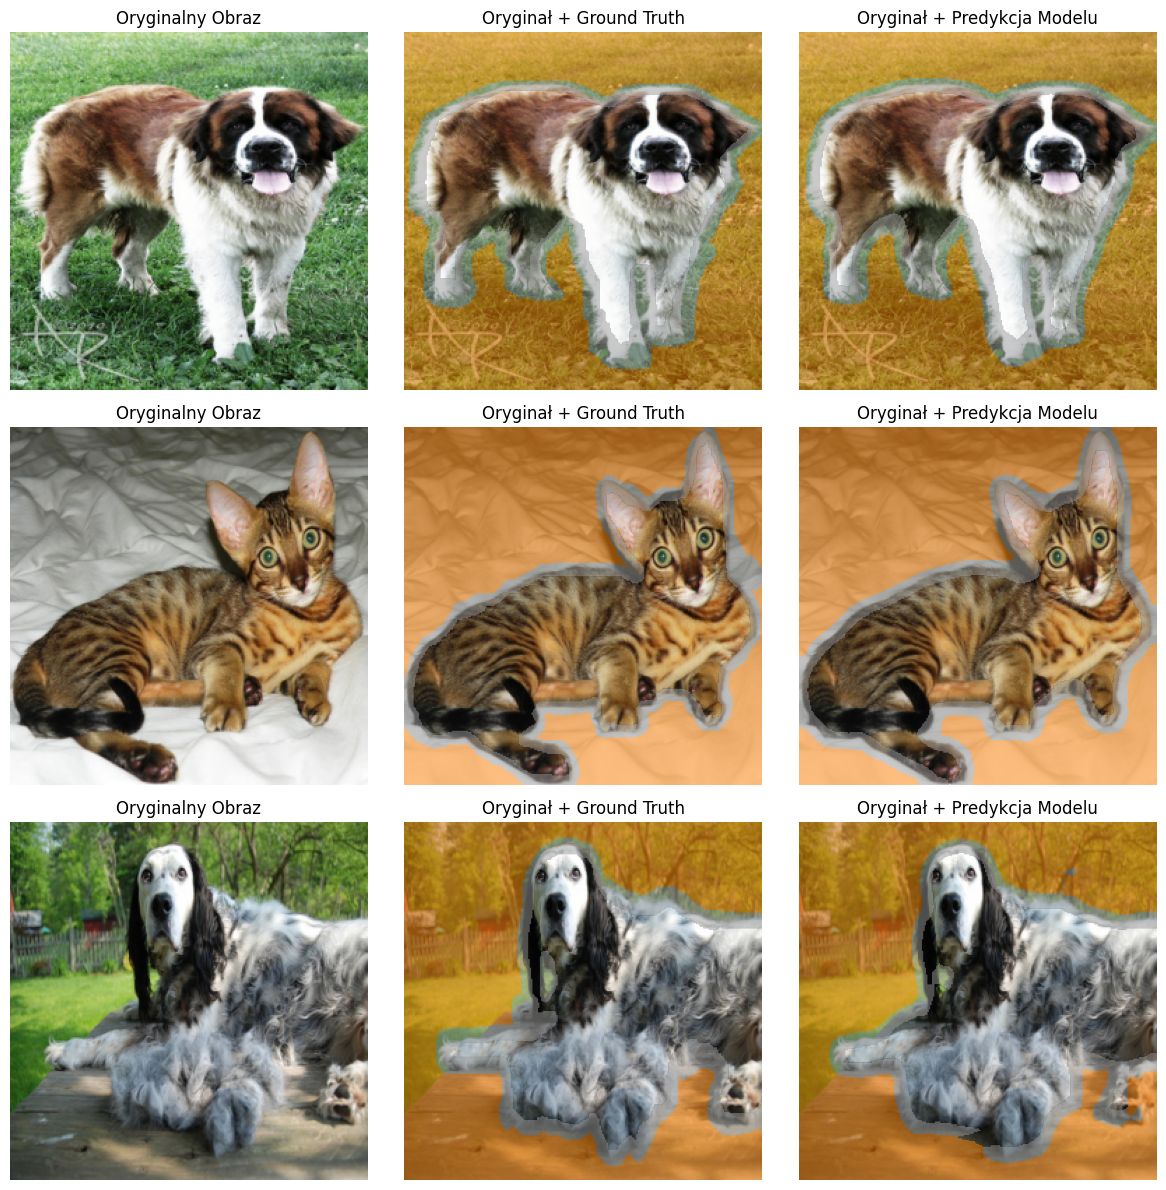

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Pobranie 3 losowych próbek ze zbioru testowego
num_samples = 3
indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        image, true_mask = test_dataset[idx]

        # dodanie wymiaru batcha
        img_input = image.unsqueeze(0).to(device)

        # Predykcja
        output = model(img_input)['out']
        pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu().numpy()

        # Obraz do wyświetlenia (C, H, W) -> (H, W, C)
        img_display = image.permute(1, 2, 0).numpy()

        # Prawdziwa maska
        true_mask_display = true_mask.numpy()

        # Rysowanie - Kolumna 1: Oryginał
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title("Oryginalny Obraz")
        axes[i, 0].axis('off')

        # Rysowanie - Kolumna 2: Oryginał + Prawdziwa Maska (Overlay)
        axes[i, 1].imshow(img_display)
        # Maskujemy tło (wartość 0), by było w pełni przezroczyste
        true_mask_overlay = np.ma.masked_where(true_mask_display == 0, true_mask_display)
        axes[i, 1].imshow(true_mask_overlay, vmin=0, vmax=2, alpha=0.5, cmap='Set1')
        axes[i, 1].set_title("Oryginał + Ground Truth")
        axes[i, 1].axis('off')

        # Rysowanie - Kolumna 3: Oryginał + Predykcja Modelu (Overlay)
        axes[i, 2].imshow(img_display)
        pred_mask_overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
        axes[i, 2].imshow(pred_mask_overlay, vmin=0, vmax=2, alpha=0.5, cmap='Set1')
        axes[i, 2].set_title("Oryginał + Predykcja Modelu")
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Analiza Błędów (Failure Case)
Model nie zawsze działa idealnie. Poniżej wyszukujemy i wizualizujemy obraz ze zbioru testowego, dla którego model uzyskał najniższy wynik mIoU (przeszukując losową podpróbkę). Pozwala to zrozumieć, w jakich warunkach sieć się myli.

Znaleziono 3 obrazy z najniższym mIoU:
1. mIoU: 0.3266 (Indeks: 47)
2. mIoU: 0.5920 (Indeks: 1760)
3. mIoU: 0.6316 (Indeks: 1847)


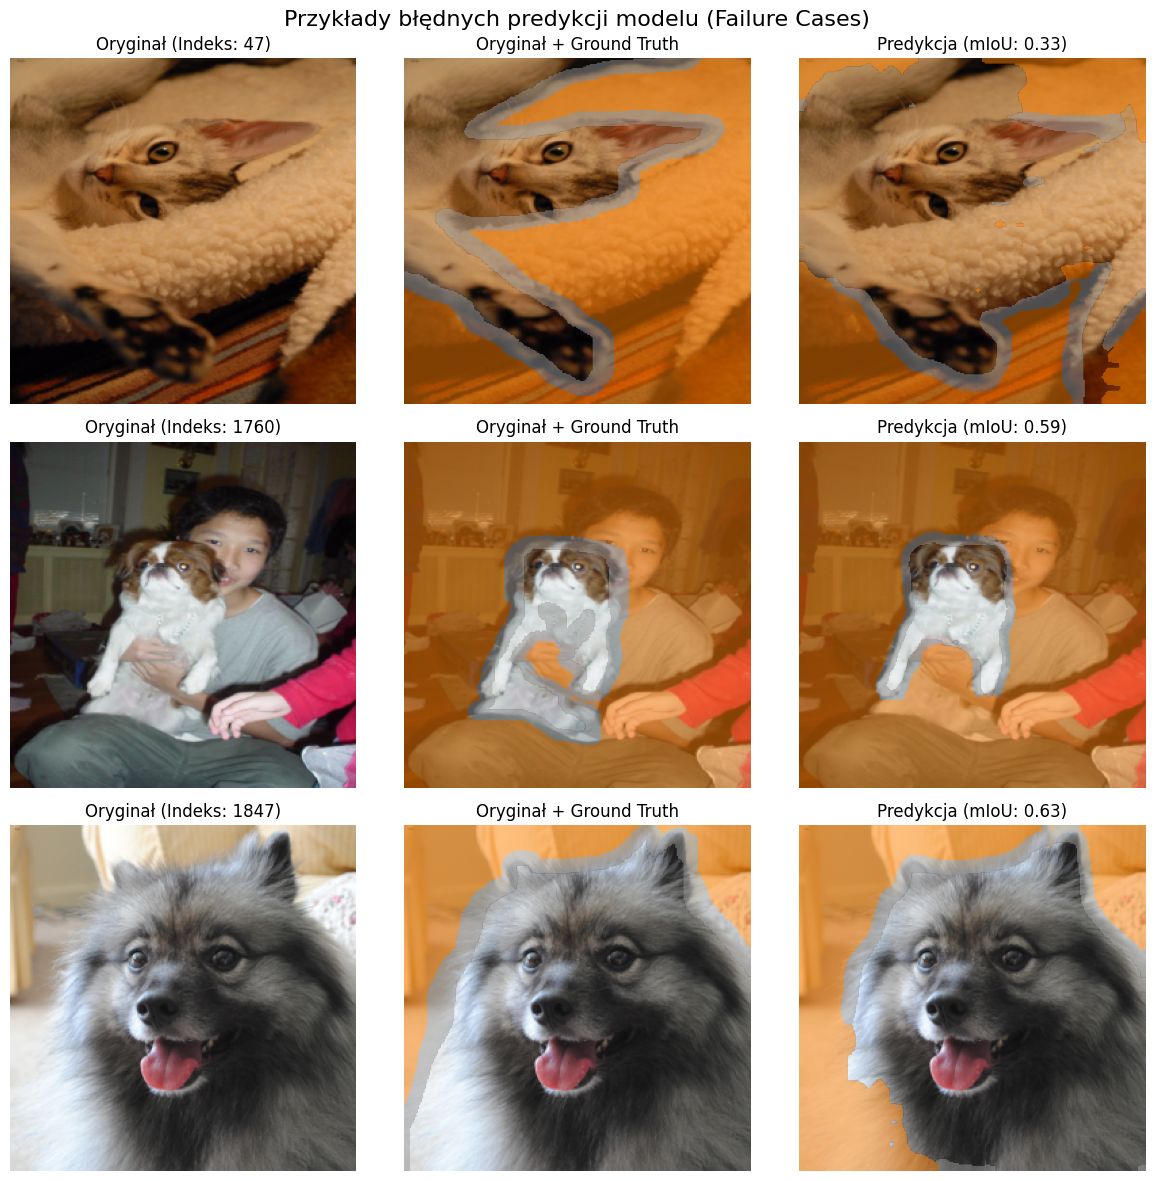

In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# Szukamy obrazów z najgorszym wynikiem IoU w podzbiorze testowym (dla szybkości sprawdzamy 100 losowych próbek)
num_search = 100
search_indices = random.sample(range(len(test_dataset)), num_search)

results = []

model.eval()
with torch.no_grad():
    for idx in search_indices:
        image, true_mask = test_dataset[idx]

        # Przygotowanie do modelu
        img_input = image.unsqueeze(0).to(device)
        output = model(img_input)['out']

        # Obliczanie IoU
        iou = calculate_iou(output.cpu(), true_mask.unsqueeze(0).cpu())
        pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu().numpy()

        results.append((iou, idx, pred_mask))

# Sortowanie rosnąco według IoU
results.sort(key=lambda x: x[0])

# Pobranie 3 najgorszych przykładów
num_worst = 3
worst_results = results[:num_worst]

print(f"Znaleziono {num_worst} obrazy z najniższym mIoU:")
for i, (iou, idx, _) in enumerate(worst_results):
    print(f"{i+1}. mIoU: {iou:.4f} (Indeks: {idx})")

fig, axes = plt.subplots(num_worst, 3, figsize=(12, 4 * num_worst))

for i, (iou, idx, pred_mask) in enumerate(worst_results):
    image, true_mask = test_dataset[idx]
    img_display = image.permute(1, 2, 0).numpy()
    true_mask_display = true_mask.numpy()

    # 1. Oryginał
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Oryginał (Indeks: {idx})")
    axes[i, 0].axis('off')

    # 2. Oryginał + Ground Truth
    axes[i, 1].imshow(img_display)
    true_mask_overlay = np.ma.masked_where(true_mask_display == 0, true_mask_display)
    axes[i, 1].imshow(true_mask_overlay, vmin=0, vmax=2, alpha=0.5, cmap='Set1')
    axes[i, 1].set_title("Oryginał + Ground Truth")
    axes[i, 1].axis('off')

    # 3. Oryginał + Predykcja modelu
    axes[i, 2].imshow(img_display)
    pred_mask_overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
    axes[i, 2].imshow(pred_mask_overlay, vmin=0, vmax=2, alpha=0.5, cmap='Set1')
    axes[i, 2].set_title(f"Predykcja (mIoU: {iou:.2f})")
    axes[i, 2].axis('off')

plt.suptitle("Przykłady błędnych predykcji modelu (Failure Cases)", fontsize=16)
plt.tight_layout()
plt.show()


## **Część 2: Segmentacja Instancji (Detekcja Pieszego)**

### **Cel:** Wykorzystanie modelu, który nie tylko znajdzie piksele należące do klasy "pieszy", ale rozróżni poszczególne osoby na obrazie (np. Pieszy 1, Pieszy 2), zwracając dla nich osobne maski oraz tzw. Bounding Boxes.

### **Wymagane Dane:**

Do tego zadania wykorzystaj **Penn-Fudan Database for Pedestrian Detection and Segmentation**. Napisz funkcję (np. z użyciem biblioteki urllib), która automatycznie pobierze i rozpakuje archiwum .zip ze strony Uniwersytetu Pensylwanii.

* **Format masek:** Maski zapisane są jako obrazy w skali szarości, gdzie tło ma wartość 0, a każdy kolejny pieszy ma przypisaną unikalną wartość całkowitą (1, 2, 3...).  
* **Zadanie inżynierii danych:** Przetwórz  tę jedną maskę z ID obiektów na zbiór $N$ masek binarnych (gdzie $N$ to liczba pieszych na danym obrazie) oraz wylicz dla nich koordynaty skrajnych punktów (Bounding Boxes [xmin, ymin, xmax, ymax]).

### **Zadania:**

1. Przygotowanie klasy Dataset zwracającej obrazy oraz słowniki z celami (targets) z kluczami: boxes, labels, masks.  
2. Załadowanie modelu **Mask R-CNN** (architektura *ResNet50_FPN*).  
3. Podmiana box_predictor oraz mask_predictor do obsługi **2 klas** (klasa 0: tło, klasa 1: pieszy).  
4. Przekazanie danych w formie listy tensorów obrazów i słowników do pętli uczącej (Mask R-CNN w trybie treningu wymaga innej struktury wejścia niż standardowe modele).  
5. Wykonanie inferencji na przykładowym obrazie i nałożenie na niego odfiltrowanych masek (o współczynniku pewności > 0.5) z użyciem biblioteki np. matplotlib.

In [10]:
import urllib.request
import zipfile
import os

# URL do zbioru Penn-Fudan
url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
zip_path = "PennFudanPed.zip"
data_dir = "data"

os.makedirs(data_dir, exist_ok=True)

print("Pobieranie zbioru Penn-Fudan...")
urllib.request.urlretrieve(url, zip_path)

print("Rozpakowywanie...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

penn_fudan_path = os.path.join(data_dir, "PennFudanPed")

print("\nStruktura folderu:", os.listdir(penn_fudan_path))

Pobieranie zbioru Penn-Fudan...
Rozpakowywanie...

Struktura folderu: ['added-object-list.txt', 'PedMasks', 'Annotation', 'PNGImages', 'readme.txt']


In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms.v2 as v2
from PIL import Image
import numpy as np
import os
from torchvision import tv_tensors

class PennFudanDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # Ładowanie wszystkich obrazów, sortowanie zapewnia zgodność obrazów i masek
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # Ścieżki do obrazu i maski
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        # Wczytanie obrazu (RGB) i maski (odcienie szarości)
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = np.array(mask)

        # Unikalne ID instancji
        obj_ids = np.unique(mask)
        # Pierwsze ID to tło, usuwamy je
        obj_ids = obj_ids[1:]

        # Rozdzielenie na N masek binarnych
        masks = mask == obj_ids[:, None, None]

        # Wyliczanie Bounding Boxes [xmin, ymin, xmax, ymax]
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # Konwersja na tensory
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # Zakładamy tylko jedną klasę (pieszy)
        labels = torch.ones((num_objs,), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        # Dodatkowe elementy często wymagane przez Mask R-CNN
        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(img.height, img.width))
        target["labels"] = labels
        target["masks"] = tv_tensors.Mask(masks)
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        img = tv_tensors.Image(img)

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

# Proste transformacje
transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
])

# Inicjalizacja zbioru i weryfikacja
dataset = PennFudanDataset(penn_fudan_path, transforms=transforms)
img, target = dataset[0]

print(f"Rozmiar zbioru: {len(dataset)}")
print(f"Kształt obrazu: {img.shape}")
print("Target:")
for k, v in target.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}")
    else:
        print(f"  {k}: {v}")